# Difracción de RX: tratamiendo de datos para NaCl y KBr

### **Joshua Briones Andrade y Jair Azarel Meléndez**
---------------------------------

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [77]:
plt.rcParams['figure.figsize'] = [8, 6]
plt.rcParams['figure.dpi'] = 100

In [72]:
names = [r"Ángulo ($2\theta$)", "Intensidad (u.a)"]

In [73]:
# ii = 63;
# angle1[ii], counts1[ii]

(126, 248)

In [107]:
# NaCl at 30kV
angle1 = [20, 22, 23, 24, 26, 28, 28.5, 29, 29.5, 30, 31,32,32.5,33,33.5,34,35,38,41,44,47,50,53,56,
          57,58,59,60,61,62,63,64,65,66,67, 68, 69, 70, 73, 76, 79, 82, 85,88,89,90,91,92,93,94,95,
          96,97,98,99,102,105,108,109,110,111,112,113,114,117,120,123,126]
counts1 = [208,865,1015,900,565,756, 1170 ,1519, 1929 ,3393,1711,2784,5462,10861,7925,4251,790,384,484,237,207,
           397,354,313,203,286,429,1139,696,271,274,319,257,598,2576,2919,360,222,204,194,251,193,217,215,189,
           194,202,201,201,186,223,328,379,229,203,210,237,239,237,478,1351,1471,316,266,245,233,249,248]
data1 = [[angle1[i], counts1[i]] for i in range(len(angle1))]
df1 = pd.DataFrame(data1, columns = names)
df1.head()

,Ángulo ($2\theta$),Intensidad (u.a)
0,20.0,208
1,22.0,865
2,23.0,1015
3,24.0,900
4,26.0,565


[]

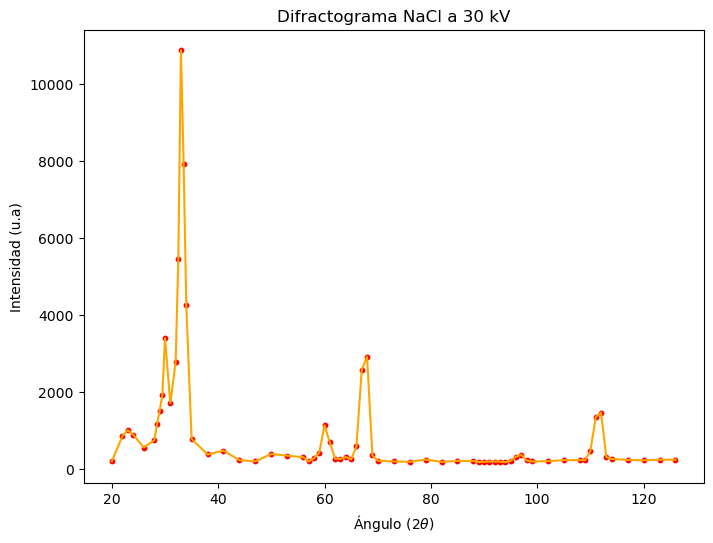

In [101]:
plt.plot(df1.to_numpy()[:,0], df1.to_numpy()[:,1], c="orange")
plt.scatter(df1.to_numpy()[:,0], df1.to_numpy()[:,1], c="red", s=10)

plt.xlabel(r"Ángulo ($2\theta$)"); plt.ylabel("Intensidad (u.a)")
plt.title("Difractograma NaCl a 30 kV")
plt.plot()

In [ ]:
# ii = 100;
# angle2[ii], counts2[ii]

In [133]:
# Kbr at 30kV
angle2 = [18,  20,  22, 24, 25, 25.5,26, 27, 27.5, 28, 28.5, 29, 30,   31, 32,   33,   34, 35, 36,   37, 38,   39,  40,
          41,  42,  43, 44, 45, 46,  47, 48,   49, 50, 51,   52, 52.5, 53, 53.5, 54,   55, 56, 57, 57.5, 58, 58.5,  59,
          59.5,60,  61, 62, 63, 64,  65, 66,   67, 68, 69,   70, 71,   72, 73,   74,   75, 76, 77,   78, 79,   80,  81,
          82,  83,  84, 85, 86, 87,  88, 89,   90, 91, 92, 92.5, 93,   94, 94.5, 95, 95.5, 96, 96.5, 97, 98,   99, 100,
          101,102, 103,104,105,106, 107,107.5,108,108.5,109, 110,  111, 112,  113, 114, 115,  116, 117,  118,  119, 120]
counts2 = [288, 219, 232, 211, 613, 736, 538, 559, 881,3091,3064,1904, 702, 210, 197, 200, 161, 147, 160, 150, 130, 141, 127,
           154, 125, 129, 137, 115, 122, 137, 129, 117, 168, 144, 243, 281, 262, 233, 180, 159, 148, 149, 142, 623, 548, 564,
           526, 370, 172, 133, 148, 140, 136, 140, 153, 144, 139, 139, 148, 145, 191, 168, 186, 161, 172, 144, 169, 133, 176,
           172, 200, 180, 193, 173, 161, 163, 173, 185, 182, 240, 290, 202, 327, 414, 417, 363, 368, 314, 222, 172, 220, 215,
           223, 212, 239, 220, 190, 186, 265, 225, 242, 217, 217, 218, 233, 218, 222, 116, 113, 211, 204, 224, 237, 203]
data2 = [[angle2[i], counts2[i]] for i in range(len(angle2))]
df2 = pd.DataFrame(data2, columns = names)
df2.head()

,Ángulo ($2\theta$),Intensidad (u.a)
0,18.0,288
1,20.0,219
2,22.0,232
3,24.0,211
4,25.0,613


[]

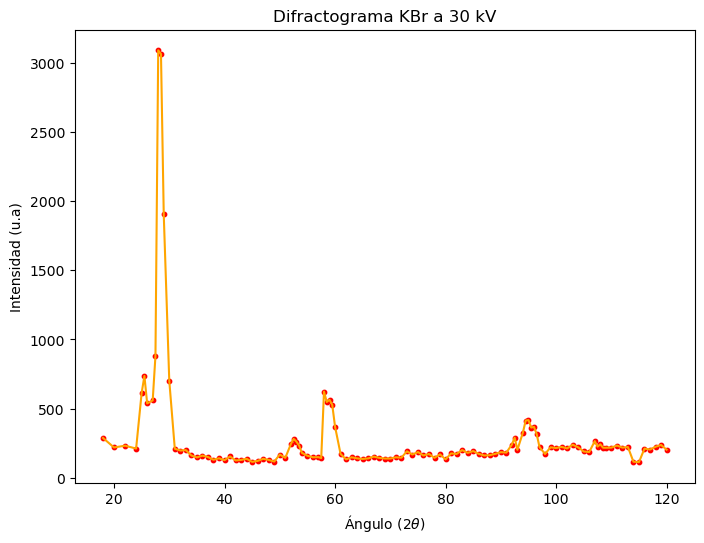

In [134]:
plt.plot(df2.to_numpy()[:,0], df2.to_numpy()[:,1], c="orange")
plt.scatter(df2.to_numpy()[:,0], df2.to_numpy()[:,1], c="red", s=10)

plt.xlabel(r"Ángulo ($2\theta$)"); plt.ylabel("Intensidad (u.a)")
plt.title("Difractograma KBr a 30 kV")
plt.plot()

In [4]:
from deap import tools
from deap import algorithms

def eaSimpleWithElitism(population, toolbox, cxpb, mutpb, ngen, stats=None,
             halloffame=None, verbose=__debug__):
    """This algorithm is similar to DEAP eaSimple() algorithm, with the modification that
    halloffame is used to implement an elitism mechanism. The individuals contained in the
    halloffame are directly injected into the next generation and are not subject to the
    genetic operators of selection, crossover and mutation.
    """
    logbook = tools.Logbook()
    logbook.header = ['gen', 'nevals'] + (stats.fields if stats else [])

    # Evaluate the individuals with an invalid fitness
    invalid_ind = [ind for ind in population if not ind.fitness.valid]
    fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    if halloffame is None:
        raise ValueError("halloffame parameter must not be empty!")

    halloffame.update(population)
    hof_size = len(halloffame.items) if halloffame.items else 0

    record = stats.compile(population) if stats else {}
    logbook.record(gen=0, nevals=len(invalid_ind), **record)
    if verbose:
        print(logbook.stream)

    # Begin the generational process
    for gen in range(1, ngen + 1):

        # Select the next generation individuals
        offspring = toolbox.select(population, len(population) - hof_size)

        # Vary the pool of individuals
        offspring = algorithms.varAnd(offspring, toolbox, cxpb, mutpb)

        # Evaluate the individuals with an invalid fitness
        invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
        fitnesses = toolbox.map(toolbox.evaluate, invalid_ind)
        for ind, fit in zip(invalid_ind, fitnesses):
            ind.fitness.values = fit

        # add the best back to population:
        offspring.extend(halloffame.items)

        # Update the hall of fame with the generated individuals
        halloffame.update(offspring)

        # Replace the current population by the offspring
        population[:] = offspring

        # Append the current generation statistics to the logbook
        record = stats.compile(population) if stats else {}
        logbook.record(gen=gen, nevals=len(invalid_ind), **record)
        if verbose:
            print(logbook.stream)

    return population, logbook